## Lab 5 — FashionMNIST CNN, инференс

Грузим веса из `best_convnet.pt`, история обучения — в `history.json`.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)


Используемое устройство: cpu


## Тестовые данные

In [2]:
classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot')

MEAN, STD = (0.2860,), (0.3530,)

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

testset = torchvision.datasets.FashionMNIST(root='./data', train=False,
                                            download=True, transform=test_transform)
testloader = DataLoader(testset, batch_size=256, shuffle=False, num_workers=2)

testset_raw = torchvision.datasets.FashionMNIST(root='./data', train=False,
                                                download=True, transform=transforms.ToTensor())

print(f'test: {len(testset)}')


100.0%
100.0%
100.0%
100.0%

Размер test: 10000


## Модель

In [3]:
class ConvNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout(0.25),

            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout(0.25),

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


net = ConvNet().to(device)
net.load_state_dict(torch.load('best_convnet.pt', map_location=device))
net.eval()


Веса загружены.


## Метрики

In [4]:
all_preds, all_labels = [], []

with torch.no_grad():
    for X, y in testloader:
        X = X.to(device)
        preds = net(X).argmax(dim=1).cpu()
        all_preds.append(preds)
        all_labels.append(y)

all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

overall_acc = (all_preds == all_labels).mean()
print(f'test acc: {overall_acc:.4f}')
print()
for cls_id, name in enumerate(classes):
    mask = all_labels == cls_id
    acc = (all_preds[mask] == cls_id).mean() if mask.any() else 0.0
    print(f'  {name:<12}: {acc:.4f}')


Итоговая accuracy на тесте: 0.9347

Accuracy по классам:
  T-shirt/top : 0.8900
  Trouser     : 0.9920
  Pullover    : 0.9060
  Dress       : 0.9300
  Coat        : 0.9290
  Sandal      : 0.9850
  Shirt       : 0.7870
  Sneaker     : 0.9770
  Bag         : 0.9920
  Ankle boot  : 0.9590


### Confusion matrix

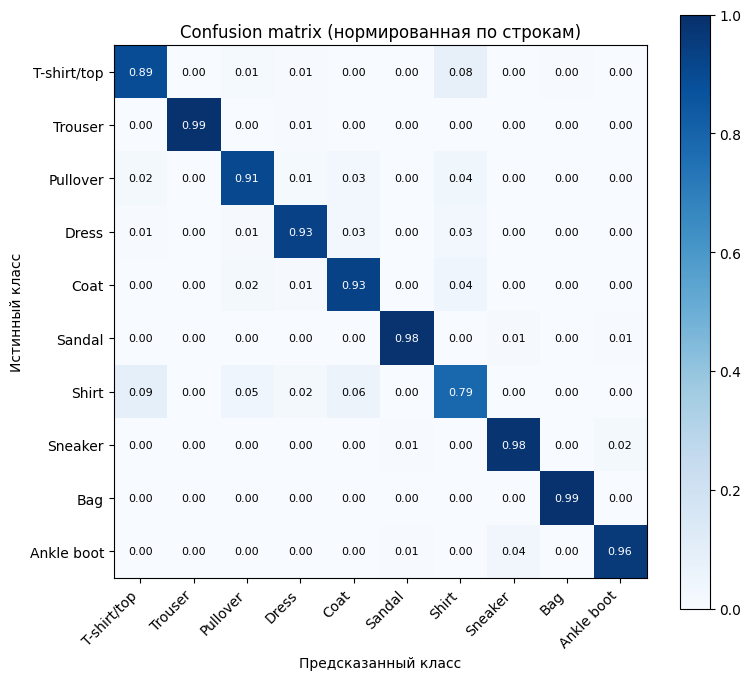

In [5]:
num_classes = len(classes)
cm = np.zeros((num_classes, num_classes), dtype=int)
for t, p in zip(all_labels, all_preds):
    cm[t, p] += 1

cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(num_classes)); ax.set_yticks(range(num_classes))
ax.set_xticklabels(classes, rotation=45, ha='right')
ax.set_yticklabels(classes)
ax.set_xlabel('pred')
ax.set_ylabel('true')

for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, f'{cm_norm[i, j]:.2f}',
                ha='center', va='center',
                color='white' if cm_norm[i, j] > 0.5 else 'black',
                fontsize=8)

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


### Кривые обучения

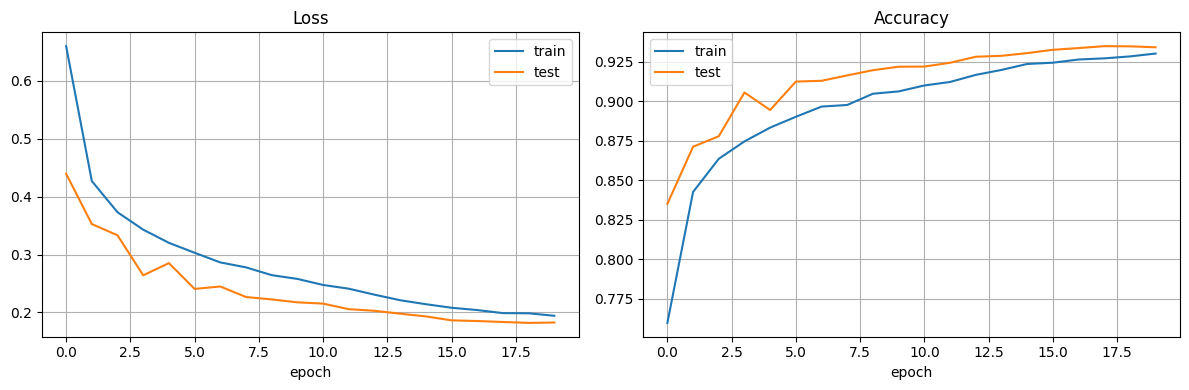

In [6]:
try:
    with open('history.json') as f:
        history = json.load(f)
except FileNotFoundError:
    history = None

if history is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history['train_loss'], label='train')
    axes[0].plot(history['test_loss'], label='test')
    axes[0].set_title('loss'); axes[0].set_xlabel('epoch'); axes[0].legend(); axes[0].grid(True)

    axes[1].plot(history['train_acc'], label='train')
    axes[1].plot(history['test_acc'], label='test')
    axes[1].set_title('accuracy'); axes[1].set_xlabel('epoch'); axes[1].legend(); axes[1].grid(True)

    plt.tight_layout()
    plt.show()


### Примеры предсказаний

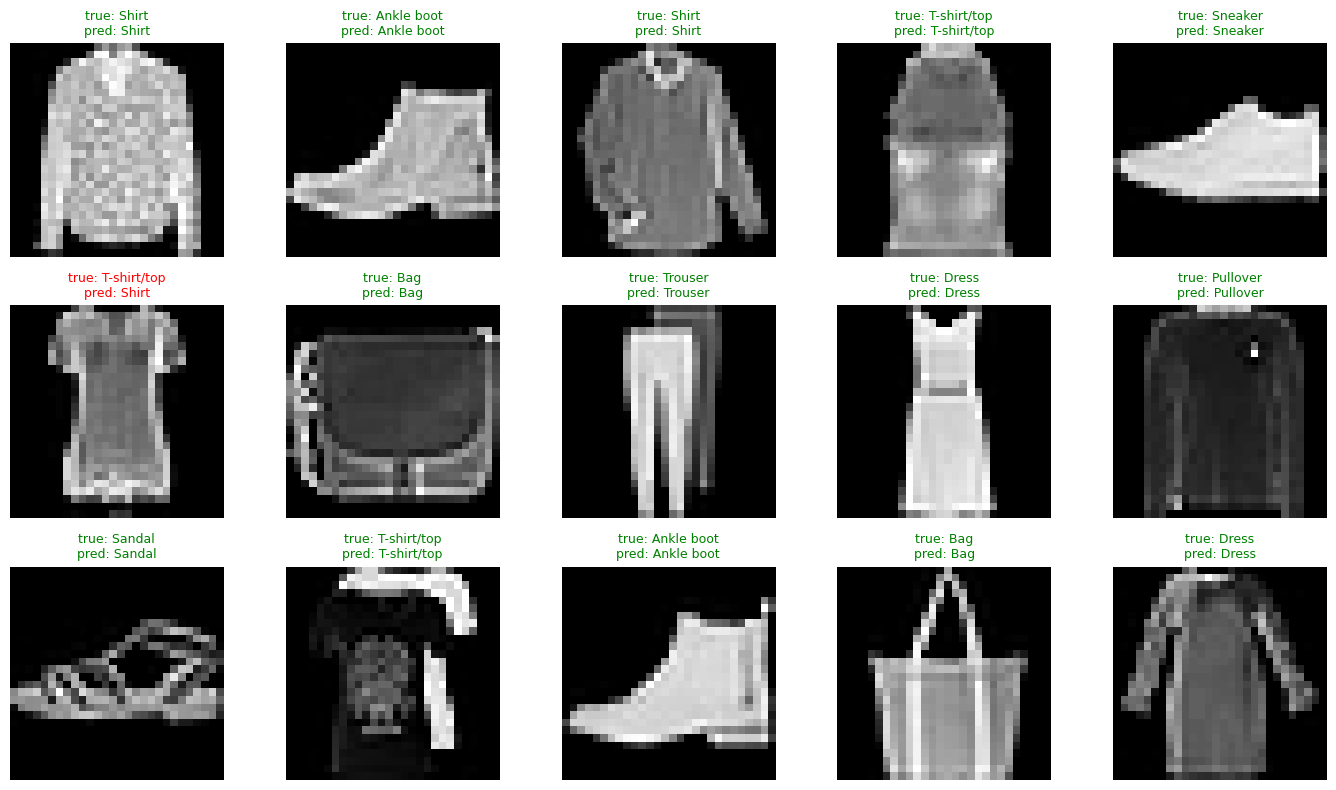

In [7]:
rng = np.random.default_rng(0)
idx = rng.choice(len(testset_raw), size=15, replace=False)

fig, axes = plt.subplots(3, 5, figsize=(14, 8))
for ax, i in zip(axes.ravel(), idx):
    img, label = testset_raw[i]
    pred = all_preds[i]
    ok = pred == label
    ax.imshow(img.squeeze().numpy(), cmap='gray')
    ax.set_title(f'true: {classes[label]}\npred: {classes[pred]}',
                 color='green' if ok else 'red', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()


### Уверенные ошибки

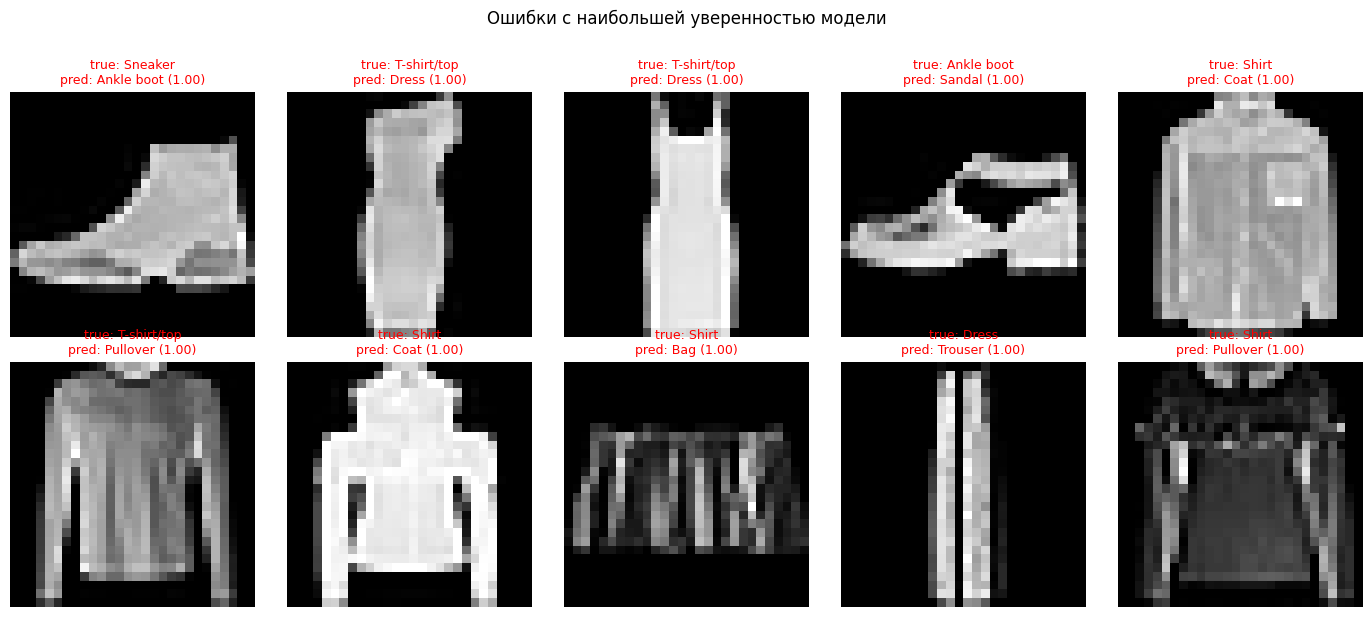

In [8]:
all_probs, all_preds_full, all_labels_full = [], [], []

with torch.no_grad():
    for X, y in testloader:
        X = X.to(device)
        probs = torch.softmax(net(X), dim=1).cpu()
        all_probs.append(probs)
        all_preds_full.append(probs.argmax(dim=1))
        all_labels_full.append(y)

all_probs = torch.cat(all_probs).numpy()
all_preds_full = torch.cat(all_preds_full).numpy()
all_labels_full = torch.cat(all_labels_full).numpy()

wrong_mask = all_preds_full != all_labels_full
wrong_idx = np.where(wrong_mask)[0]
confidences = all_probs[wrong_idx, all_preds_full[wrong_idx]]
top_wrong = wrong_idx[np.argsort(-confidences)[:10]]

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, i in zip(axes.ravel(), top_wrong):
    img, label = testset_raw[i]
    pred = all_preds_full[i]
    conf = all_probs[i, pred]
    ax.imshow(img.squeeze().numpy(), cmap='gray')
    ax.set_title(f'true: {classes[label]}\npred: {classes[pred]} ({conf:.2f})',
                 color='red', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()
